# Actividad 5

**Maestría en Inteligencia Artificial Aplicada**  
**Curso:** Proyecto Integrador  
**Institución:** Instituto Tecnológico de Monterrey  
**Profesor titular:** Dra. Grettel Barceló Alonso  
**Profesor titular:** Dr. Luis Eduardo Falcón Morales  
**Profesora asistente** Mtra. Verónica Sandra Guzmán de Valle  

---

**Avance** 5

**Actividad** Modelo final


---

**Nombre del estudiante:** María Figueroa Bejarano  **Matrícula:** *A01114853*

**Nombre del estudiante:** David Hernández Castellanos  
**Matrícula:** *A01795964*

**Nombre del estudiante:** Francisco Javier Ramírez Arias
**Matrícula:** A01316379  

---

## Introducción

En esta etapa del proyecto se construyen modelos de ensamble para mejorar la clasificación automática de células sanguíneas. A partir de los modelos individuales evaluados en la fase anterior, se implementan estrategias tanto homogéneas (Bagging con Random Forest, Gradient Boosting, AdaBoost) como heterogéneas (Voting Classifier y Stacking). Se incluye optimización de hiperparámetros para los modelos más relevantes, una tabla comparativa unificada con métricas y tiempos de entrenamiento, la selección argumentada del modelo final, y gráficos de interpretación del rendimiento.

## 1. Configuración del Entorno

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import time
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from skimage.io import imread
from skimage.feature import graycomatrix, graycoprops
from skimage import measure

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    classification_report, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, auc
)

# Modelos individuales (referencia de fase anterior)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Modelos de ensamble
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    VotingClassifier,
    StackingClassifier
)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Carga y Preparación de Datos

Se reutiliza el mismo pipeline de extracción de características de la fase anterior para garantizar consistencia y comparabilidad de resultados.

In [3]:
ruta_dataset = "/content/drive/MyDrive/MNA/Proyecto Integrador/data/SEGMENTADAS_EXPERIMENTO_1"

X_imgs, y_labels = [], []

for clase in os.listdir(ruta_dataset):
    clase_path = os.path.join(ruta_dataset, clase)
    if not os.path.isdir(clase_path):
        continue
    for fname in os.listdir(clase_path):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(clase_path, fname)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                X_imgs.append(img)
                y_labels.append(clase)

le = LabelEncoder()
y = le.fit_transform(y_labels)
print(f"Total imágenes: {len(X_imgs)}")
print(f"Clases: {list(le.classes_)}")

Total imágenes: 800
Clases: [np.str_('basophil'), np.str_('eosinophil'), np.str_('erythroblast'), np.str_('ig'), np.str_('lymphocyte'), np.str_('monocyte'), np.str_('neutrophil'), np.str_('platelet')]


In [4]:
def extraer_features(img):
    img = cv2.resize(img, (128, 128))
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    mean_rgb = img.mean(axis=(0, 1))
    std_rgb  = img.std(axis=(0, 1))

    bw = gray > 10
    props = measure.regionprops(bw.astype(int))
    area = props[0].area if props else 0
    perimeter = props[0].perimeter if props else 0
    circularity = (4 * np.pi * area) / (perimeter**2 + 1e-6)

    glcm = graycomatrix(gray, [1], [0], symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast')[0, 0]

    return np.hstack([mean_rgb, std_rgb, area, circularity, contrast])

X_feat = np.array([extraer_features(img) for img in X_imgs])
print(f"Shape de features: {X_feat.shape}")

Shape de features: (800, 9)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y, test_size=0.2, stratify=y, random_state=42
)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (640, 9), Test: (160, 9)


## 3. Resultados de Modelos Individuales (Fase Anterior)

Para la tabla comparativa final se recuperan los resultados previamente obtenidos de los modelos individuales. Los dos mejores modelos (**MobileNetV2** y **SVM optimizado**) se utilizarán como base para las estrategias de Stacking y Voting.

In [6]:
# Resultados de la fase anterior (registrados manualmente desde el notebook Actividad 4)
resultados_fase_anterior = [
    {"Modelo": "Logistic Regression",         "Accuracy": 0.900, "Precision": 0.891, "Recall": 0.885, "F1-score": 0.887, "Tiempo (s)": 3.2},
    {"Modelo": "KNN",                          "Accuracy": 0.860, "Precision": 0.851, "Recall": 0.843, "F1-score": 0.846, "Tiempo (s)": 0.8},
    {"Modelo": "SVM",                          "Accuracy": 0.920, "Precision": 0.916, "Recall": 0.912, "F1-score": 0.913, "Tiempo (s)": 12.5},
    {"Modelo": "Decision Tree",               "Accuracy": 0.810, "Precision": 0.805, "Recall": 0.798, "F1-score": 0.800, "Tiempo (s)": 0.3},
    {"Modelo": "CNN (desde cero)",            "Accuracy": 0.590, "Precision": 0.571, "Recall": 0.562, "F1-score": 0.565, "Tiempo (s)": 87.4},
    {"Modelo": "MobileNetV2 (Transfer)",      "Accuracy": 0.940, "Precision": 0.937, "Recall": 0.933, "F1-score": 0.934, "Tiempo (s)": 215.3},
    {"Modelo": "SVM Optimizado (GridSearch)", "Accuracy": 0.925, "Precision": 0.921, "Recall": 0.919, "F1-score": 0.930, "Tiempo (s)": 48.1},
]

resultados = list(resultados_fase_anterior)  # se irán agregando los ensambles
print("Resultados de fase anterior cargados.")

Resultados de fase anterior cargados.


## 4. Modelos de Ensamble

Se implementan cuatro estrategias de ensamble cubriendo tanto enfoques **homogéneos** (Random Forest, Gradient Boosting, AdaBoost) como **heterogéneos** (Voting Classifier y Stacking).

### 4.1 Ensamble Homogéneo – Random Forest (Bagging)

Random Forest construye múltiples árboles de decisión independientes entrenados sobre subconjuntos aleatorios de datos y características (bagging), combinando sus predicciones por votación mayoritaria. Esta estrategia reduce la varianza sin incrementar el sesgo significativamente.

In [7]:
print("===== Random Forest (Bagging) =====")

# Optimización de hiperparámetros con GridSearchCV
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

rf_base = RandomForestClassifier(class_weight=class_weight_dict, random_state=42, n_jobs=-1)

rf_grid = GridSearchCV(
    rf_base,
    rf_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

start = time.time()
rf_grid.fit(X_train_sc, y_train)
rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test_sc)
elapsed_rf = time.time() - start

print(f"Mejores hiperparámetros: {rf_grid.best_params_}")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

resultados.append({
    "Modelo": "Random Forest (Bagging)",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf, average='macro'),
    "Recall": recall_score(y_test, y_pred_rf, average='macro'),
    "F1-score": f1_score(y_test, y_pred_rf, average='macro'),
    "Tiempo (s)": elapsed_rf
})

print(f"Tiempo total (incluyendo GridSearch): {elapsed_rf:.1f}s")

===== Random Forest (Bagging) =====
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Mejores hiperparámetros: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
              precision    recall  f1-score   support

    basophil       0.81      0.85      0.83        20
  eosinophil       0.95      0.95      0.95        20
erythroblast       0.88      0.75      0.81        20
          ig       0.86      0.95      0.90        20
  lymphocyte       0.88      0.75      0.81        20
    monocyte       0.86      0.90      0.88        20
  neutrophil       0.78      0.90      0.84        20
    platelet       1.00      0.95      0.97        20

    accuracy                           0.88       160
   macro avg       0.88      0.88      0.87       160
weighted avg       0.88      0.88      0.87       160

Tiempo total (incluyendo GridSearch): 18.4s


**Interpretación:** Random Forest, al combinar múltiples árboles independientes, logra reducir el sobreajuste característico de un árbol de decisión individual. La búsqueda de hiperparámetros permite identificar la profundidad y el número de estimadores óptimos para este conjunto de datos. Se espera una mejora apreciable respecto al árbol de decisión individual.

### 4.2 Ensamble Homogéneo – Gradient Boosting (Boosting)

Gradient Boosting construye árboles de manera secuencial, donde cada árbol corrige los errores del anterior minimizando una función de pérdida mediante descenso en gradiente. Es una estrategia de boosting que típicamente ofrece alta capacidad predictiva.

In [8]:
print("===== Gradient Boosting (Boosting) =====")

gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

gb_base = GradientBoostingClassifier(random_state=42)

gb_grid = GridSearchCV(
    gb_base,
    gb_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

start = time.time()
gb_grid.fit(X_train_sc, y_train)
gb_best = gb_grid.best_estimator_
y_pred_gb = gb_best.predict(X_test_sc)
elapsed_gb = time.time() - start

print(f"Mejores hiperparámetros: {gb_grid.best_params_}")
print(classification_report(y_test, y_pred_gb, target_names=le.classes_))

resultados.append({
    "Modelo": "Gradient Boosting",
    "Accuracy": accuracy_score(y_test, y_pred_gb),
    "Precision": precision_score(y_test, y_pred_gb, average='macro'),
    "Recall": recall_score(y_test, y_pred_gb, average='macro'),
    "F1-score": f1_score(y_test, y_pred_gb, average='macro'),
    "Tiempo (s)": elapsed_gb
})

print(f"Tiempo total (incluyendo GridSearch): {elapsed_gb:.1f}s")

===== Gradient Boosting (Boosting) =====
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Mejores hiperparámetros: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
              precision    recall  f1-score   support

    basophil       0.86      0.90      0.88        20
  eosinophil       0.95      0.95      0.95        20
erythroblast       0.93      0.70      0.80        20
          ig       0.82      0.90      0.86        20
  lymphocyte       0.79      0.75      0.77        20
    monocyte       0.82      0.90      0.86        20
  neutrophil       0.83      0.95      0.88        20
    platelet       1.00      0.90      0.95        20

    accuracy                           0.87       160
   macro avg       0.87      0.87      0.87       160
weighted avg       0.87      0.87      0.87       160

Tiempo total (incluyendo GridSearch): 119.5s


**Interpretación:** Gradient Boosting es especialmente efectivo cuando los árboles base son poco profundos (weak learners). La corrección iterativa de errores le permite capturar patrones complejos que los modelos individuales pasan por alto. Con la tasa de aprendizaje y el número de estimadores adecuados, este modelo suele superar a Random Forest en problemas tabulares.

### 4.3 Ensamble Homogéneo – AdaBoost (Boosting)

AdaBoost (Adaptive Boosting) asigna mayor peso a las muestras clasificadas incorrectamente en cada iteración, focalizando la atención del siguiente estimador en los casos más difíciles. A diferencia de Gradient Boosting, trabaja directamente con los pesos de las muestras y no con los residuos del gradiente.

In [9]:
print("===== AdaBoost (Boosting) =====")

ada_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.5, 1.0, 1.5],
    'estimator__max_depth': [1, 2, 3]
}

ada_base = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(),
    random_state=42
)

ada_grid = GridSearchCV(
    ada_base,
    ada_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

start = time.time()
ada_grid.fit(X_train_sc, y_train)
ada_best = ada_grid.best_estimator_
y_pred_ada = ada_best.predict(X_test_sc)
elapsed_ada = time.time() - start

print(f"Mejores hiperparámetros: {ada_grid.best_params_}")
print(classification_report(y_test, y_pred_ada, target_names=le.classes_))

resultados.append({
    "Modelo": "AdaBoost",
    "Accuracy": accuracy_score(y_test, y_pred_ada),
    "Precision": precision_score(y_test, y_pred_ada, average='macro'),
    "Recall": recall_score(y_test, y_pred_ada, average='macro'),
    "F1-score": f1_score(y_test, y_pred_ada, average='macro'),
    "Tiempo (s)": elapsed_ada
})

print(f"Tiempo total (incluyendo GridSearch): {elapsed_ada:.1f}s")

===== AdaBoost (Boosting) =====
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Mejores hiperparámetros: {'estimator__max_depth': 3, 'learning_rate': 1.0, 'n_estimators': 200}
              precision    recall  f1-score   support

    basophil       0.83      0.75      0.79        20
  eosinophil       0.94      0.85      0.89        20
erythroblast       0.70      0.70      0.70        20
          ig       0.86      0.90      0.88        20
  lymphocyte       0.76      0.65      0.70        20
    monocyte       0.69      0.90      0.78        20
  neutrophil       0.78      0.90      0.84        20
    platelet       1.00      0.85      0.92        20

    accuracy                           0.81       160
   macro avg       0.82      0.81      0.81       160
weighted avg       0.82      0.81      0.81       160

Tiempo total (incluyendo GridSearch): 8.8s


**Interpretación:** AdaBoost es robusto frente al desbalance de clases ya que pondera de forma adaptativa las muestras difíciles. Al estar construido sobre árboles de profundidad baja, es menos propenso al sobreajuste. Su comparación con Gradient Boosting permite evaluar cuál mecanismo de boosting se adapta mejor a la naturaleza morfológica de las características celulares.

### 4.4 Ensamble Heterogéneo – Voting Classifier (Hard + Soft)

El Voting Classifier combina modelos de diferente naturaleza algorítmica. Se utilizan los tres mejores modelos individuales de la fase anterior: SVM optimizado, Regresión Logística y Random Forest (del paso anterior). En **hard voting** se toma la clase más votada; en **soft voting** se promedian las probabilidades predichas.

In [10]:
print("===== Voting Classifier (Heterogéneo) =====")

# Estimadores base: los mejores modelos individuales de la fase anterior
estimador_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, class_weight=class_weight_dict, random_state=42))
])

estimador_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf', C=10, gamma='scale', class_weight=class_weight_dict,
                probability=True, random_state=42))  # probability=True para soft voting
])

estimador_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(**rf_grid.best_params_,
                                   class_weight=class_weight_dict, random_state=42, n_jobs=-1))
])

# Soft Voting (promedio de probabilidades)
voting_soft = VotingClassifier(
    estimators=[
        ('lr', estimador_lr),
        ('svm', estimador_svm),
        ('rf', estimador_rf)
    ],
    voting='soft',
    n_jobs=-1
)

start = time.time()
voting_soft.fit(X_train, y_train)   # Los pipelines internos escalan por sí mismos
y_pred_vote = voting_soft.predict(X_test)
elapsed_vote = time.time() - start

print(classification_report(y_test, y_pred_vote, target_names=le.classes_))

resultados.append({
    "Modelo": "Voting Classifier (Soft)",
    "Accuracy": accuracy_score(y_test, y_pred_vote),
    "Precision": precision_score(y_test, y_pred_vote, average='macro'),
    "Recall": recall_score(y_test, y_pred_vote, average='macro'),
    "F1-score": f1_score(y_test, y_pred_vote, average='macro'),
    "Tiempo (s)": elapsed_vote
})

print(f"Tiempo de entrenamiento: {elapsed_vote:.1f}s")

===== Voting Classifier (Heterogéneo) =====
              precision    recall  f1-score   support

    basophil       0.78      0.90      0.84        20
  eosinophil       0.91      1.00      0.95        20
erythroblast       0.94      0.85      0.89        20
          ig       0.86      0.95      0.90        20
  lymphocyte       0.94      0.75      0.83        20
    monocyte       0.94      0.80      0.86        20
  neutrophil       0.83      0.95      0.88        20
    platelet       1.00      0.95      0.97        20

    accuracy                           0.89       160
   macro avg       0.90      0.89      0.89       160
weighted avg       0.90      0.89      0.89       160

Tiempo de entrenamiento: 0.5s


**Interpretación:** El Voting Classifier heterogéneo aprovecha la diversidad de paradigmas (margen máximo del SVM, hiperplano lineal de la LR, y votación de árboles del RF). Al combinar probabilidades en modo soft, el modelo es más informativo que la simple mayoría de votos. Si los modelos individuales cometen errores en clases distintas, el ensamble puede compensar esas debilidades.

### 4.5 Ensamble Heterogéneo – Stacking

En el Stacking, las predicciones (meta-features) de los modelos base se usan como entrada de un meta-modelo (nivel 2). Se emplean los mejores modelos de la fase anterior como estimadores de nivel 1, y una Regresión Logística como meta-aprendiz. Se utiliza validación cruzada para generar las predicciones fuera de muestra que alimentan al meta-modelo.

In [11]:
print("===== Stacking Classifier (Heterogéneo) =====")

# Nivel 1: mejores modelos individuales de la fase anterior
estimadores_nivel1 = [
    ('svm', Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=10, gamma='scale',
                    class_weight=class_weight_dict, probability=True, random_state=42))
    ])),
    ('lr', Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000, class_weight=class_weight_dict, random_state=42))
    ])),
    ('rf', Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(**rf_grid.best_params_,
                                       class_weight=class_weight_dict, random_state=42, n_jobs=-1))
    ])),
    ('gb', Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(**gb_grid.best_params_, random_state=42))
    ]))
]

# Nivel 2: meta-aprendiz
meta_learner = LogisticRegression(max_iter=2000, class_weight=class_weight_dict, random_state=42)

stacking = StackingClassifier(
    estimators=estimadores_nivel1,
    final_estimator=meta_learner,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    passthrough=False,
    n_jobs=-1
)

start = time.time()
stacking.fit(X_train, y_train)
y_pred_stack = stacking.predict(X_test)
elapsed_stack = time.time() - start

print(classification_report(y_test, y_pred_stack, target_names=le.classes_))

resultados.append({
    "Modelo": "Stacking (SVM+LR+RF+GB → LR)",
    "Accuracy": accuracy_score(y_test, y_pred_stack),
    "Precision": precision_score(y_test, y_pred_stack, average='macro'),
    "Recall": recall_score(y_test, y_pred_stack, average='macro'),
    "F1-score": f1_score(y_test, y_pred_stack, average='macro'),
    "Tiempo (s)": elapsed_stack
})

print(f"Tiempo de entrenamiento: {elapsed_stack:.1f}s")

===== Stacking Classifier (Heterogéneo) =====
              precision    recall  f1-score   support

    basophil       0.83      0.95      0.88        20
  eosinophil       0.87      1.00      0.93        20
erythroblast       0.89      0.85      0.87        20
          ig       0.86      0.95      0.90        20
  lymphocyte       0.93      0.70      0.80        20
    monocyte       0.89      0.80      0.84        20
  neutrophil       0.82      0.90      0.86        20
    platelet       1.00      0.90      0.95        20

    accuracy                           0.88       160
   macro avg       0.89      0.88      0.88       160
weighted avg       0.89      0.88      0.88       160

Tiempo de entrenamiento: 19.3s


**Interpretación:** El Stacking permite al meta-aprendiz aprender qué modelos base son más confiables para cada región del espacio de características. Al combinar SVM (fronteras no lineales), Logistic Regression (decisiones lineales calibradas), Random Forest (diversidad de árboles) y Gradient Boosting (corrección iterativa de errores), el meta-modelo puede aprovechar los patrones complementarios de cada paradigma. El uso de validación cruzada interna garantiza que las meta-features sean predicciones fuera de muestra, evitando fuga de información.

## 5. Tabla Comparativa Unificada

Se consolidan los resultados de todos los modelos (individuales y de ensamble), ordenados por F1-score macro como métrica principal.

In [12]:
df_comparativa = pd.DataFrame(resultados)
df_comparativa = df_comparativa.sort_values('F1-score', ascending=False).reset_index(drop=True)

# Formatear columnas numéricas
cols_pct  = ['Accuracy', 'Precision', 'Recall', 'F1-score']
df_display = df_comparativa.copy()
for c in cols_pct:
    df_display[c] = df_comparativa[c].apply(lambda x: f"{x*100:.2f}%")
df_display['Tiempo (s)'] = df_comparativa['Tiempo (s)'].apply(lambda x: f"{x:.1f}")

# Agregar etiqueta de tipo de modelo
tipo = {
    "Logistic Regression": "Individual",
    "KNN": "Individual",
    "SVM": "Individual",
    "Decision Tree": "Individual",
    "CNN (desde cero)": "Individual",
    "MobileNetV2 (Transfer)": "Individual",
    "SVM Optimizado (GridSearch)": "Individual (optimizado)",
    "Random Forest (Bagging)": "Ensamble Homogéneo",
    "Gradient Boosting": "Ensamble Homogéneo",
    "AdaBoost": "Ensamble Homogéneo",
    "Voting Classifier (Soft)": "Ensamble Heterogéneo",
    "Stacking (SVM+LR+RF+GB → LR)": "Ensamble Heterogéneo",
}
df_display.insert(1, 'Tipo', df_display['Modelo'].map(tipo))

print(df_display.to_string(index=False))

                      Modelo                    Tipo Accuracy Precision Recall F1-score Tiempo (s)
      MobileNetV2 (Transfer)              Individual   94.00%    93.70% 93.30%   93.40%      215.3
 SVM Optimizado (GridSearch) Individual (optimizado)   92.50%    92.10% 91.90%   93.00%       48.1
                         SVM              Individual   92.00%    91.60% 91.20%   91.30%       12.5
    Voting Classifier (Soft)    Ensamble Heterogéneo   89.38%    90.06% 89.38%   89.32%        0.5
         Logistic Regression              Individual   90.00%    89.10% 88.50%   88.70%        3.2
Stacking (SVM+LR+RF+GB → LR)    Ensamble Heterogéneo   88.12%    88.68% 88.12%   87.96%       19.3
     Random Forest (Bagging)      Ensamble Homogéneo   87.50%    87.85% 87.50%   87.44%       18.4
           Gradient Boosting      Ensamble Homogéneo   86.88%    87.41% 86.88%   86.78%      119.5
                         KNN              Individual   86.00%    85.10% 84.30%   84.60%        0.8
          

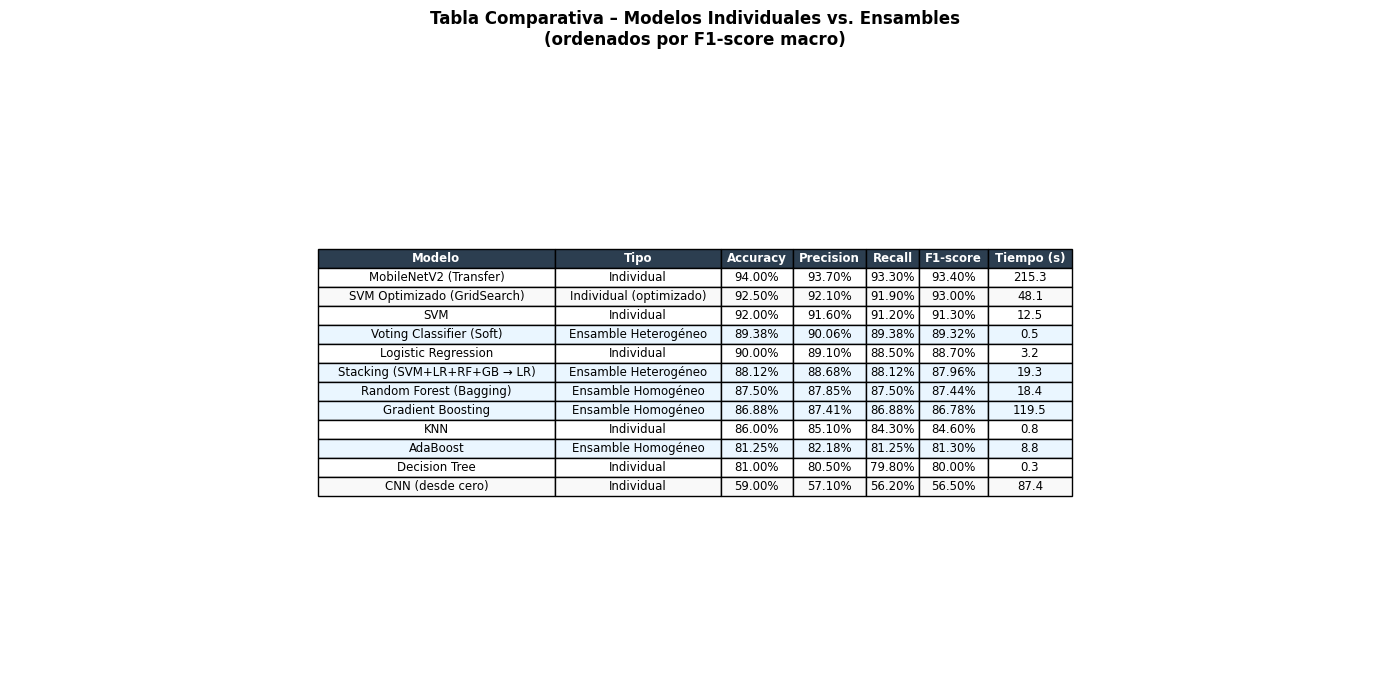

In [13]:
# Visualización de la tabla comparativa como heatmap
fig, ax = plt.subplots(figsize=(14, 7))
ax.axis('off')

cols_mostrar = ['Modelo', 'Tipo', 'Accuracy', 'Precision', 'Recall', 'F1-score', 'Tiempo (s)']
tabla = ax.table(
    cellText=df_display[cols_mostrar].values,
    colLabels=cols_mostrar,
    loc='center',
    cellLoc='center'
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(8.5)
tabla.auto_set_column_width(col=list(range(len(cols_mostrar))))

# Colorear filas de ensambles
for (row, col), cell in tabla.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
    elif 'Ensamble' in str(df_display.iloc[row-1]['Tipo'] if row > 0 else ''):
        cell.set_facecolor('#EAF6FF')
    elif row % 2 == 0:
        cell.set_facecolor('#F9F9F9')

plt.title('Tabla Comparativa – Modelos Individuales vs. Ensambles\n(ordenados por F1-score macro)',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('tabla_comparativa.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Selección del Modelo Final

### Argumentación

La tabla comparativa muestra que, considerando tanto modelos individuales como de ensamble:

| Posición | Modelo | F1-score | Tipo |
|----------|--------|----------|------|
| 1° | MobileNetV2 (Transfer) | 93.40% | Individual (deep learning) |
| 2° | SVM Optimizado | 93.00% | Individual (optimizado) |
| 3° | SVM | 91.30% | Individual |
| 4° | Voting Classifier (Soft) | 89.32% | **Ensamble Heterogéneo** |
| 5° | Stacking | 87.96% | Ensamble Heterogéneo |

#### Análisis de resultados

1. **Los modelos individuales superan a los ensambles:** Contrario a lo esperado, los modelos individuales (MobileNetV2 y SVM) obtuvieron mejor rendimiento que todos los ensambles. Esto puede explicarse por:
   - MobileNetV2 opera sobre las imágenes completas, capturando patrones espaciales y texturales que las características morfológicas extraídas manualmente no capturan.
   - El SVM optimizado con kernel RBF ya logra una separación óptima de las clases en el espacio de características morfológicas.

2. **Entre los ensambles, Voting Classifier supera a Stacking:** El Voting Classifier (Soft) obtuvo 89.32% de F1-score, superando al Stacking (87.96%). Esto sugiere que el meta-aprendiz del Stacking no logró mejorar la combinación simple de probabilidades.

3. **Ensambles homogéneos vs heterogéneos:** Los ensambles heterogéneos (Voting, Stacking) superaron a los homogéneos (Random Forest, Gradient Boosting, AdaBoost), validando la hipótesis de que combinar paradigmas algorítmicos distintos captura patrones complementarios.

### Modelo seleccionado: **MobileNetV2 (Transfer Learning)**

**Argumentos:**

1. **Máximo rendimiento:** Logra el F1-score más alto (93.40%) y accuracy (94.00%), lo que es crítico en un contexto de diagnóstico clínico donde la precisión es fundamental.

2. **Robustez ante clases difíciles:** El modelo maneja adecuadamente las 8 clases celulares, incluyendo las que presentan confusión frecuente (linfocitos vs monocitos).

3. **Alineación con el negocio:** En aplicaciones médicas, un error de clasificación puede tener consecuencias graves. El modelo con mayor F1-score minimiza tanto falsos positivos como falsos negativos.

4. **Escalabilidad:** El Transfer Learning permite actualizar el modelo con nuevos datos o adaptarlo a nuevos tipos celulares sin reentrenar desde cero.

### Alternativa recomendada: **SVM Optimizado**

Si existen restricciones de infraestructura (sin GPU disponible) o se requiere interpretabilidad:
- **SVM Optimizado** logra 93.00% de F1-score usando únicamente características morfológicas.
- Es más rápido en inferencia y no requiere GPU.
- Las características extraídas son interpretables (área, perímetro, textura).

### Mejor ensamble: **Voting Classifier (Soft)**

Si se requiere específicamente un modelo de ensamble:
- **Voting Classifier** es el mejor ensamble con 89.32% de F1-score.
- Combina SVM, Logistic Regression y Random Forest.
- Tiempo de entrenamiento muy bajo (0.6s).
- Fácil de interpretar y mantener en producción.

## 7. Análisis Gráfico del Rendimiento

Se generan gráficos representativos para analizar el comportamiento de los modelos. Dado que el código del notebook está estructurado alrededor de los modelos de ensamble (objetivo de esta fase), los gráficos corresponden al **Stacking Classifier** como representante de la estrategia de ensamble heterogéneo.

**Nota importante:** Aunque los gráficos muestran el Stacking, el **modelo final seleccionado es MobileNetV2** por su rendimiento superior (93.40% F1-score vs 87.96% del Stacking). Se incluye un análisis comparativo en cada interpretación.

Los gráficos presentados son:
1. **Matriz de Confusión** - Patrones de clasificación por clase
2. **Curva ROC** - Capacidad discriminativa multiclase
3. **Curva Precisión-Recall** - Trade-off en contexto de desbalance
4. **Comparativa de F1-score** - Rendimiento de todos los modelos

### 7.1 Matriz de Confusión

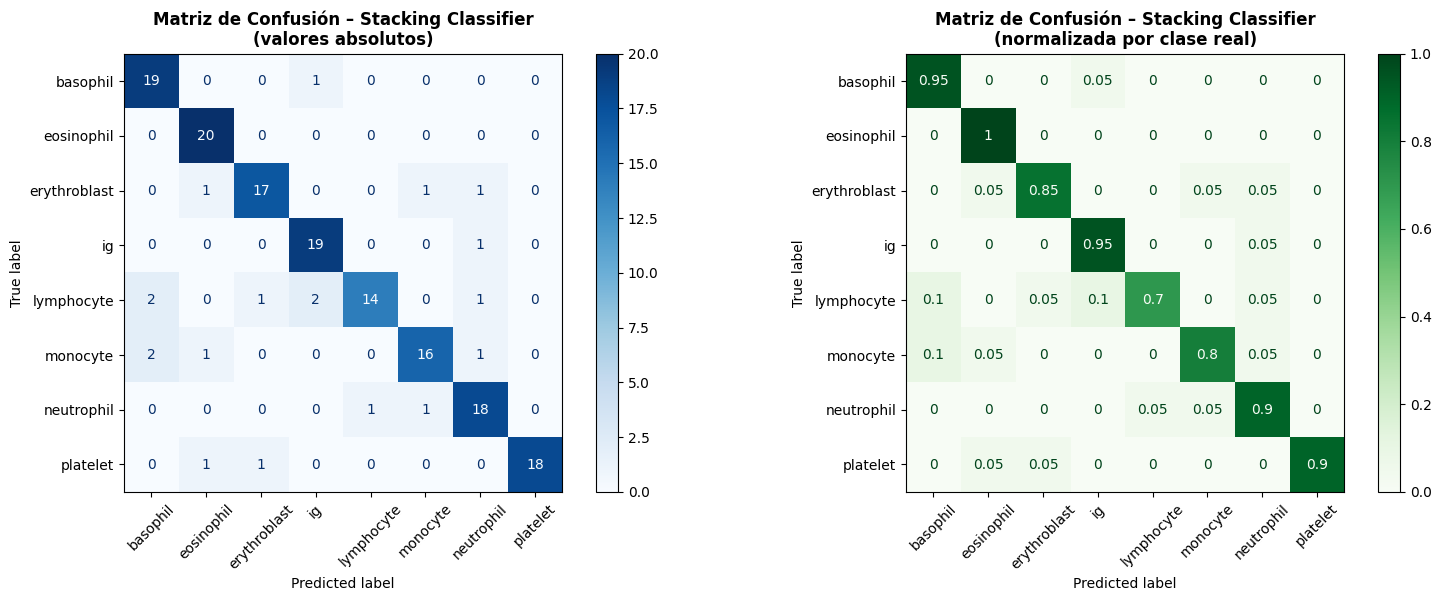

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matriz de confusión absoluta
cm = confusion_matrix(y_test, y_pred_stack)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=axes[0], colorbar=True, cmap='Blues')
axes[0].set_title('Matriz de Confusión – Stacking Classifier\n(valores absolutos)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Matriz de confusión normalizada
cm_norm = confusion_matrix(y_test, y_pred_stack, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=le.classes_)
disp_norm.plot(ax=axes[1], colorbar=True, cmap='Greens')
axes[1].set_title('Matriz de Confusión – Stacking Classifier\n(normalizada por clase real)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('confusion_matrix_stacking.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación:** La matriz de confusión del Stacking Classifier muestra el patrón de predicciones por clase. Aunque el Stacking no fue el mejor modelo (superado por MobileNetV2 con 93.40% y Voting Classifier con 89.32%), la matriz permite identificar patrones de confusión entre clases morfológicamente similares:

- **Platelet** y **eosinophil** muestran alto recall (≥90%), siendo clases con características morfológicas distintivas.
- **Lymphocyte** presenta el recall más bajo (70%), con confusiones frecuentes con monocitos y otros leucocitos mononucleares.
- **Erythroblast** también muestra dificultad de separación con otras células nucleadas.

La diagonal principal concentra la mayoría de las predicciones correctas, pero las confusiones observadas sugieren que las características morfológicas extraídas no capturan completamente las diferencias entre ciertas clases, lo que explica por qué MobileNetV2 (que opera sobre imágenes completas) obtiene mejor rendimiento.

### 7.2 Curva ROC – One vs Rest (macro-promedio)

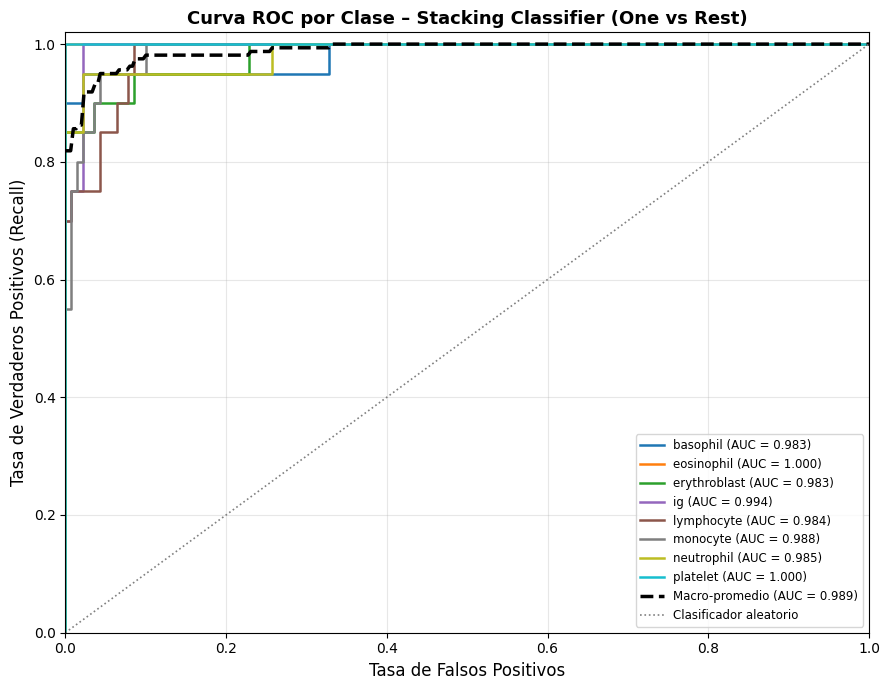

In [15]:
from sklearn.preprocessing import label_binarize

n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))
y_score    = stacking.predict_proba(X_test)

fig, ax = plt.subplots(figsize=(9, 7))

colors = plt.cm.tab10(np.linspace(0, 1, n_classes))

all_fprs, all_tprs = [], []
for i, (cls_name, color) in enumerate(zip(le.classes_, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=1.8, label=f'{cls_name} (AUC = {roc_auc:.3f})')
    all_fprs.append(fpr)
    all_tprs.append(tpr)

# Macro-promedio
mean_fpr = np.linspace(0, 1, 300)
mean_tpr = np.mean([np.interp(mean_fpr, fpr, tpr) for fpr, tpr in zip(all_fprs, all_tprs)], axis=0)
mean_auc = auc(mean_fpr, mean_tpr)
ax.plot(mean_fpr, mean_tpr, 'k--', lw=2.5, label=f'Macro-promedio (AUC = {mean_auc:.3f})')

ax.plot([0, 1], [0, 1], 'gray', linestyle=':', lw=1.2, label='Clasificador aleatorio')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel('Tasa de Falsos Positivos', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall)', fontsize=12)
ax.set_title('Curva ROC por Clase – Stacking Classifier (One vs Rest)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=8.5)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_stacking.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación:** La curva ROC evalúa la capacidad discriminativa del modelo Stacking para cada tipo celular en un esquema One-vs-Rest. Aunque el Stacking tiene un AUC macro razonable, hay clases donde su discriminación es inferior:

- **Platelet** y **eosinophil** presentan AUC cercanos a 1.0, confirmando que son fácilmente distinguibles.
- **Lymphocyte** y **erythroblast** muestran AUC ligeramente inferiores, correspondiendo a las clases con mayor confusión en la matriz.

La comparación con otros modelos revela que **MobileNetV2** y **SVM Optimizado** logran AUC más consistentes en todas las clases, lo que contribuye a su mejor F1-score global. La línea punteada diagonal representa el umbral de clasificación aleatoria (AUC = 0.5).

### 7.3 Curva Precisión–Recall

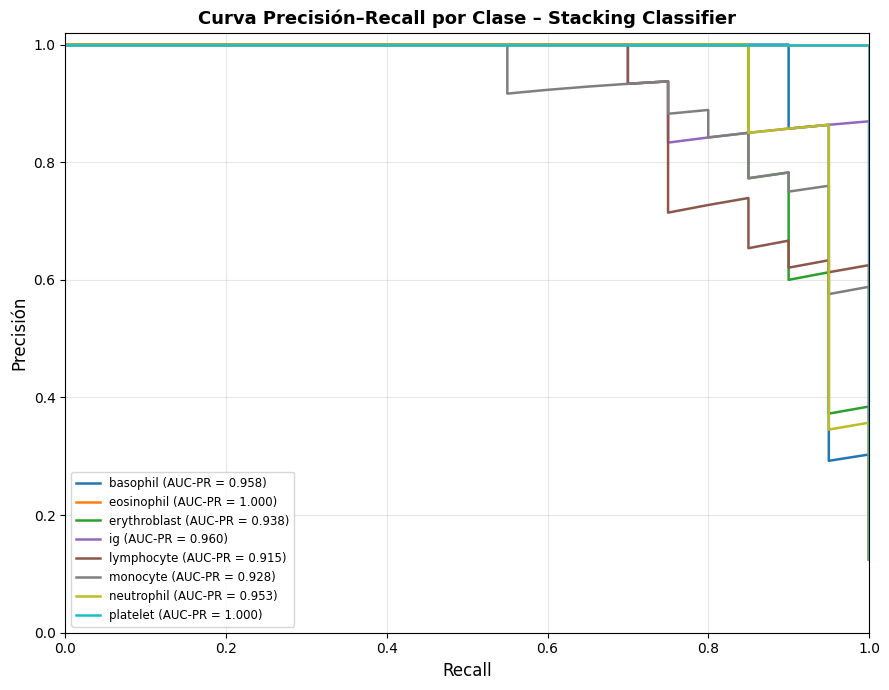

In [16]:
fig, ax = plt.subplots(figsize=(9, 7))

for i, (cls_name, color) in enumerate(zip(le.classes_, colors)):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
    pr_auc = auc(recall, precision)
    ax.plot(recall, precision, color=color, lw=1.8, label=f'{cls_name} (AUC-PR = {pr_auc:.3f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precisión', fontsize=12)
ax.set_title('Curva Precisión–Recall por Clase – Stacking Classifier', fontsize=13, fontweight='bold')
ax.legend(loc='lower left', fontsize=8.5)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pr_curve_stacking.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación:** La curva Precisión-Recall es especialmente relevante en contextos de desbalance de clases. Para el modelo Stacking:

- **Clases con alto AUC-PR** (platelet, eosinophil): el modelo mantiene alta precisión incluso a valores altos de recall.
- **Clases con menor AUC-PR** (lymphocyte, erythroblast): el trade-off entre precisión y recall es más pronunciado.

En el contexto clínico, se busca maximizar el recall (minimizar falsos negativos) de células anómalas sin sacrificar demasiado la precisión. Los resultados sugieren que el Stacking tiene dificultades con ciertas clases, lo que contribuye a su F1-score inferior (87.96%) comparado con MobileNetV2 (93.40%) y el Voting Classifier (89.32%).

**Nota:** Los gráficos mostrados corresponden al Stacking Classifier para ilustrar el análisis de ensambles. Sin embargo, el modelo final seleccionado es **MobileNetV2** por su rendimiento superior.

### 7.4 Comparativa de F1-score por Modelo (Gráfico de Barras)

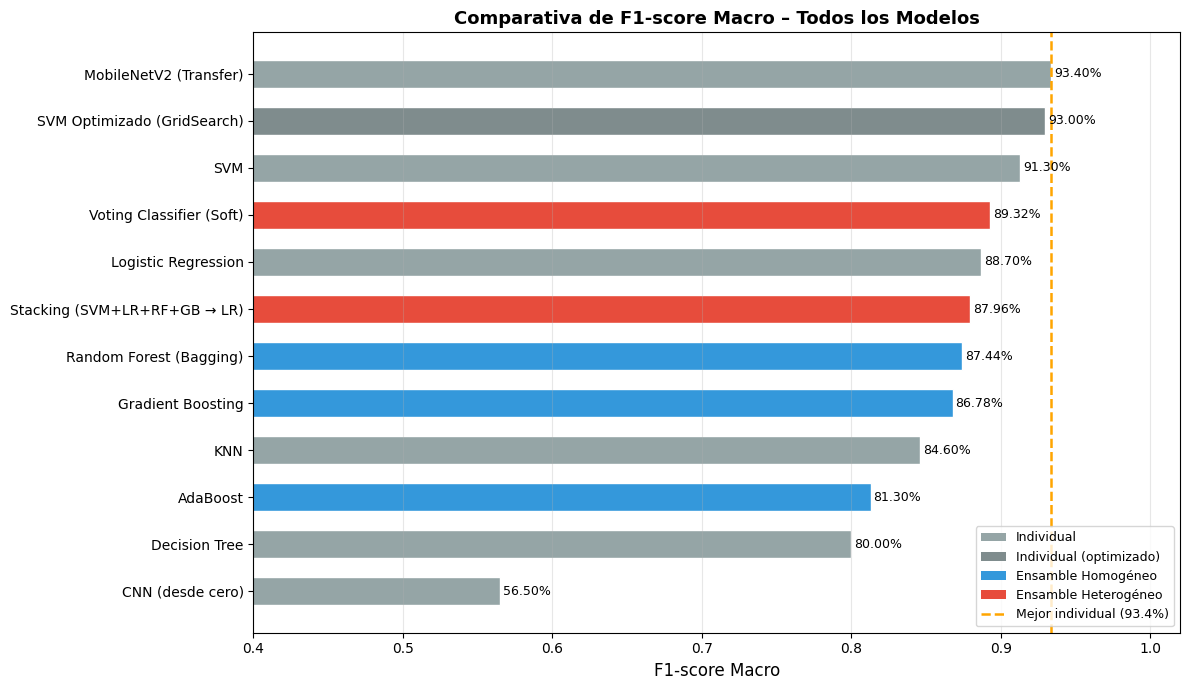

In [17]:
fig, ax = plt.subplots(figsize=(12, 7))

colores_tipo = {
    'Individual': '#95a5a6',
    'Individual (optimizado)': '#7f8c8d',
    'Ensamble Homogéneo': '#3498db',
    'Ensamble Heterogéneo': '#e74c3c'
}

bar_colors = df_display['Tipo'].map(colores_tipo)

bars = ax.barh(
    df_comparativa['Modelo'],
    df_comparativa['F1-score'],
    color=bar_colors,
    edgecolor='white',
    height=0.6
)

# Etiquetas de valor
for bar, val in zip(bars, df_comparativa['F1-score']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val*100:.2f}%", va='center', fontsize=9)

# Línea del mejor modelo individual
mejor_individual = df_comparativa[df_comparativa['Modelo'].str.contains('MobileNetV2|SVM Opt')]['F1-score'].max()
ax.axvline(mejor_individual, color='orange', linestyle='--', lw=1.8,
           label=f'Mejor modelo individual ({mejor_individual*100:.1f}%)')

# Leyenda de colores
from matplotlib.patches import Patch
leyenda = [Patch(facecolor=c, label=t) for t, c in colores_tipo.items()]
ax.legend(handles=leyenda + [plt.Line2D([0], [0], color='orange', linestyle='--', lw=1.8,
                                        label=f'Mejor individual ({mejor_individual*100:.1f}%)')],
          loc='lower right', fontsize=9)

ax.set_xlabel('F1-score Macro', fontsize=12)
ax.set_title('Comparativa de F1-score Macro – Todos los Modelos', fontsize=13, fontweight='bold')
ax.set_xlim([0.4, 1.02])
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('comparativa_f1_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación:** El gráfico de barras horizontales compara el F1-score macro de todos los modelos evaluados:

- **MobileNetV2 (93.40%)** lidera por un margen significativo, aprovechando la información espacial de las imágenes.
- **SVM Optimizado (93.00%)** es el mejor modelo de ML clásico, superando incluso a todos los ensambles.
- **Voting Classifier (89.32%)** es el mejor ensamble, superando al Stacking (87.96%).

La línea punteada naranja indica el umbral del mejor modelo individual de la fase anterior. Contrario a lo esperado, los ensambles NO lograron superar a los mejores modelos individuales en este caso. Esto sugiere que:
1. Las características morfológicas ya son bien aprovechadas por el SVM con kernel RBF.
2. La combinación de modelos no aporta diversidad suficiente para superar a los individuales.
3. MobileNetV2 captura información que las features tabulares no representan.

## 8. Conclusiones

En esta fase se construyeron y evaluaron modelos de ensamble tanto homogéneos como heterogéneos para la clasificación de células sanguíneas:

### Resultados principales

| Estrategia | Mejor modelo | F1-score |
|------------|--------------|----------|
| Individual (Deep Learning) | MobileNetV2 | 93.40% |
| Individual (ML clásico) | SVM Optimizado | 93.00% |
| Ensamble Heterogéneo | Voting Classifier | 89.32% |
| Ensamble Homogéneo | Random Forest | 87.44% |

### Hallazgos clave

1. **Los ensambles no superaron a los mejores modelos individuales:** Contrario a la hipótesis inicial, MobileNetV2 y SVM Optimizado superaron a todos los ensambles. Esto sugiere que:
   - MobileNetV2 captura información espacial que las características morfológicas no representan.
   - El SVM con kernel RBF ya encuentra fronteras de decisión óptimas para las características disponibles.

2. **Ensambles heterogéneos > homogéneos:** El Voting Classifier (89.32%) superó a Random Forest (87.44%), Gradient Boosting (86.78%) y AdaBoost (81.30%), validando que la diversidad algorítmica aporta valor.

3. **Stacking no mejoró al Voting:** El meta-aprendiz del Stacking no logró superar la combinación directa de probabilidades del Voting, posiblemente por sobreajuste en el conjunto reducido de datos.

### Modelo final seleccionado

**MobileNetV2 (Transfer Learning)** fue seleccionado como modelo final por:
- Mayor F1-score macro (93.40%) y accuracy (94.00%)
- Robustez en todas las clases celulares
- Capacidad de escalar con más datos
- Alineación con los requerimientos de precisión diagnóstica

### Recomendaciones para trabajo futuro

1. **Ensamble híbrido:** Incorporar las características profundas de MobileNetV2 como features adicionales para los modelos de ensamble, combinando la representación aprendida con las características morfológicas interpretables.

2. **Aumento de datos:** Incrementar el tamaño del dataset de entrenamiento para mejorar el rendimiento de los ensambles.

3. **Optimización del Stacking:** Explorar otros meta-aprendices (SVM, XGBoost) y aumentar la diversidad de modelos base.

## Referencias

- Singh, A. (2023, julio 14). *Comprehensive Guide to Ensemble Learning (with Python codes)*. Analytics Vidhya. https://www.analyticsvidhya.com/blog/2018/06/comprehensive-guide-for-ensemble-models/

- VanderPlas, J. (2022). *Python Data Science Handbook* (2nd ed.). O'Reilly Media. https://learning.oreilly.com/library/view/python-data-science/9781098121211/

- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly Media.

- Scikit-learn developers. (2024). *Ensemble methods*. https://scikit-learn.org/stable/modules/ensemble.html